In [2]:
import pandas as pd
import cv2
from matplotlib import pyplot as plt
import numpy as np
import json

In [75]:
projections = pd.read_csv('./indiana_projections.csv')
reports = pd.read_csv('./indiana_reports.csv')

combined = pd.merge(projections, reports, on='uid')

combined.head()

,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression
0,1,1_IM-0001-4001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,1,1_IM-0001-3001.dcm.png,Lateral,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,2,2_IM-0652-1001.dcm.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
3,2,2_IM-0652-2001.dcm.png,Lateral,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
4,3,3_IM-1384-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."


In [76]:
# Create up to 3 filename columns per uid
tmp = combined.copy()
tmp["img_num"] = tmp.groupby("uid").cumcount() + 1

image_cols = (
    tmp.pivot(index="uid", columns="img_num", values="filename")
       .reindex(columns=[1, 2, 3])
       .rename(columns={1: "image_1", 2: "image_2", 3: "image_3"})
       .reset_index()
)

# Keep one row of the remaining metadata per uid
meta_cols = [c for c in combined.columns if c not in ["filename", "projection"]]
uid_merged = combined[meta_cols].groupby("uid", as_index=False).first()

uid_merged = uid_merged.merge(image_cols, on="uid", how="left")

uid_merged.head()

,uid,MeSH,Problems,image,indication,comparison,findings,impression,image_1,image_2,image_3
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,1_IM-0001-4001.dcm.png,1_IM-0001-3001.dcm.png,NaN
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.,2_IM-0652-1001.dcm.png,2_IM-0652-2001.dcm.png,NaN
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p...",3_IM-1384-1001.dcm.png,3_IM-1384-2001.dcm.png,NaN
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,4_IM-2050-1001.dcm.png,4_IM-2050-2001.dcm.png,NaN
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.,5_IM-2117-1003002.dcm.png,5_IM-2117-1004003.dcm.png,NaN


In [77]:
import xml.etree.ElementTree as ET

def build_mesh_lookup(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    mesh_lookup = {}

    for descriptor in root.findall(".//DescriptorRecord"):
        name_elem = descriptor.find("./DescriptorName/String")
        if name_elem is None:
            continue
        
        term = name_elem.text.strip()

        tree_numbers = []
        for tree_num in descriptor.findall("./TreeNumberList/TreeNumber"):
            tree_numbers.append(tree_num.text.strip())

        if tree_numbers:
            mesh_lookup[term] = tree_numbers

    return mesh_lookup

def build_qualifier_lookup(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    qualifier_lookup = {}

    for record in root.findall(".//QualifierRecord"):
        name_elem = record.find("./QualifierName/String")
        if name_elem is None:
            continue
        
        name = name_elem.text.strip().lower()

        tree_numbers = []
        for tree_num in record.findall("./TreeNumberList/TreeNumber"):
            tree_numbers.append(tree_num.text.strip())

        qualifier_lookup[name] = tree_numbers

    return qualifier_lookup 

if 0:
    mesh_lookup = build_mesh_lookup("desc2026.xml")
    qualifiers = build_qualifier_lookup("qual2026.xml")

    with open("mesh_lookup.json", "w") as f:
        json.dump(mesh_lookup, f)

    with open("qualifier_lookup.json", "w") as f:
        json.dump(qualifiers, f)


In [78]:
with open("../lookup_data/mesh_lookup.json") as f:
    mesh_lookup = json.load(f)

with open("../lookup_data/qualifier_lookup.json") as f:
    qualifiers = json.load(f)

def is_anatomy(term):
    return any(code.startswith("A") for code in mesh_lookup.get(term, []))

def is_disease(term):
    return any(code.startswith("C") for code in mesh_lookup.get(term, []))

def is_pathology_modifier(mod):
    return mod.lower() in qualifiers


def classify(term):
    codes = mesh_lookup.get(term, [])
    if any(c.startswith("C") for c in codes):
        return "Disease"
    if any(c.startswith("A") for c in codes):
        return "Anatomy"
    return "Other"

In [79]:
def parse_mesh_annotation(annotation_string):
    concepts = annotation_string.split(";")
    parsed = []

    for concept in concepts:
        parts = [p.strip() for p in concept.split("/") if p.strip()]
        if not parts:
            continue
        
        parsed.append({
            "base": parts[0],
            "modifiers": parts[1:]
        })

    return clean(parsed)

def clean(parsed):
    cleaned = []
    for item in parsed:
        mods = [m for m in item["modifiers"] if m.lower() != "base"]
        cleaned.append({
            "base": item["base"],
            "modifiers": mods
        })
    return cleaned

RAD_DESCRIPTORS = {
    # Lungs / pulmonary
    "hyperdistention": "Lung hyperdistention",
    "hypoinflation": "Lung hypoinflation",
    "opacity": "Pulmonary opacity",
    "airspace disease": "Airspace disease",
    "pulmonary congestion": "Pulmonary congestion",
    "interstitial": "Interstitial pattern",
    "focal": "Focal abnormality",
    "diffuse": "Diffuse abnormality",
    "streaky": "Streaky opacity",
    "patchy": "Patchy opacity",
    "round": "Round opacity",
    "small": "Small opacity",
    "bilateral": "Bilateral abnormality",
    "prominent": "Prominent finding",
    "obscured": "Obscured anatomy",
    "markings": "Pulmonary markings",

    # Cardiac / vessels
    "cardiac shadow": "Abnormal cardiac shadow",
    "borderline": "Borderline finding",
    "enlarged": "Enlarged structure",
    "tortuous": "Tortuous vessel",
    "epicardial fat": "Prominent epicardial fat",
    
    # Diaphragm / angles
    "elevated": "Elevated diaphragm",
    "blunted": "Blunted costophrenic angle",
    
    # Masses / nodules
    "nodule": "Pulmonary nodule",
    "mass": "Pulmonary mass",
    "cavitation": "Pulmonary cavitation",
    "calcified granuloma": "Calcified granuloma",
    
    # Devices / instruments
    "surgical instruments": "Surgical instruments",
    "catheters, indwelling": "Indwelling catheter",
    "stents": "Coronary stent",
    "implanted medical device": "Implanted medical device",
    "tube, inserted": "Inserted tube",
    "contrast media": "Contrast media",
    "sutures": "Sutures",
    "breast implants": "Breast implant",
    "mastectomy": "Mastectomy",

    
    # Bones / spine
    "deformity": "Deformity",
    "osteophyte": "Osteophyte",
    "degenerative": "Degenerative change",
    "granulomatous disease": "Granulomatous disease",
}

def normalize_indication_field(text):
    if not isinstance(text, str):
        return None

    text = text.lower()

    CLINICAL_MAP = {
        "chest pain": "Chest pain",
        "hodgkin": "Hodgkin lymphoma",
        "hypertension": "Hypertension",
        # expand as needed
    }

    for key, value in CLINICAL_MAP.items():
        if key in text:
            return value

    return None

def normalize_impression(text):
    if not isinstance(text, str):
        return None

    text = text.lower()

    if "no acute" in text:
        return "Normal"

    if "postoperative" in text:
        return "Postoperative change"

    if "pneumonia" in text:
        return "Pneumonia"

    return None

def extract_diagnosis(item):
    base = item["base"]
    modifiers = item["modifiers"]

    if base == 'normal':
        return "Normal"
    
    if is_disease(base):
        return base

    if is_anatomy(base):
        for m in modifiers:
            if is_disease(m) or is_pathology_modifier(m):
                return f"{m} {base}"
            
    if not modifiers and not is_disease(base) and not is_anatomy(base):
        return "Normal"


    return None 

RAD_BASE_FINDINGS = {
    "lucency": "Lucency",
    "medical device": "Medical device",
    "spinal fusion": "Spinal fusion",
}


def extract_radiology(item):
    base = item["base"].lower()
    modifiers = [m.lower() for m in item["modifiers"]]

    if base == "normal":
        return "Normal"

    for m in modifiers:
        if m in RAD_DESCRIPTORS:
            return f"{RAD_DESCRIPTORS[m]} in {item['base']}"

    if base in RAD_BASE_FINDINGS:
        location = " ".join(item["modifiers"])
        if location:
            return f"{RAD_BASE_FINDINGS[base]} in {location}"
        return RAD_BASE_FINDINGS[base]

    if base in RAD_DESCRIPTORS:
        return RAD_DESCRIPTORS[base]

    return None



In [80]:
if 0:
    mesh_annotations = uid_merged['MeSH'].tolist()
    parsed_annotations = [parse_mesh_annotation(annotation) for annotation in mesh_annotations]

    for item in parsed_annotations:
        diags = []
        for concept in item:
            diag = extract_diagnosis(concept)
            if diag is not None:
                diags.append(diag)
        if len(diags) == 0:
            diag = [extract_radiology(item[0]) if item else None]
            print(diag)
        else:
            sorted_ = sorted(diags, key=lambda x: 0 if is_disease(x) else 1)
            if len(sorted_) > 1 and "Normal" in sorted_:
                sorted_ = [x for x in sorted_ if x != "Normal"]
            print(set(sorted_))

Size before dropping rows with missing findings: 3851
Size after dropping rows with missing findings: 3337
Percentage of rows dropped due to missing findings: 13.35%


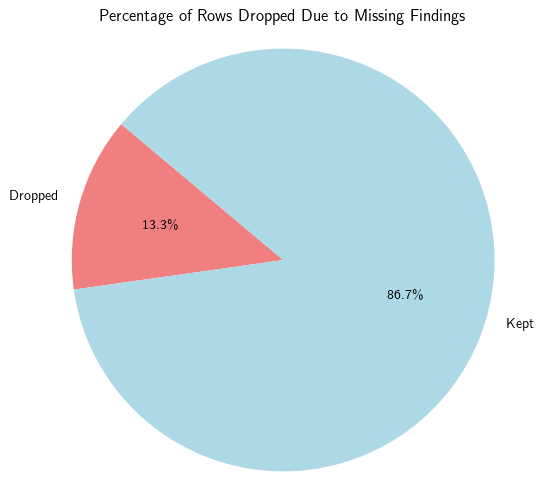

In [81]:
size_before = uid_merged.shape[0]
uid_merged.dropna(subset=['findings'], inplace=True)
after_size = uid_merged.shape[0]

print(f"Size before dropping rows with missing findings: {size_before}")
print(f"Size after dropping rows with missing findings: {after_size}")

percent_dropped = (size_before - after_size) / size_before * 100
print(f"Percentage of rows dropped due to missing findings: {percent_dropped:.2f}%")

# plot a pie chart % of rows dropped
labels = ['Dropped', 'Kept']
sizes = [percent_dropped, 100 - percent_dropped]
colors = ['lightcoral', 'lightblue']
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Rows Dropped Due to Missing Findings')
plt.axis('equal')
plt.show()

In [82]:
uid_merged.duplicated(subset=['findings']).sum()

np.int64(784)

In [83]:
def normalize_mesh_field(field):
    parsed = parse_mesh_annotation(field)
    diags = []
    for concept in parsed:
        diag = extract_diagnosis(concept)
        if diag is not None:
            diags.append(diag)
    if len(diags) == 0:
        diag = extract_radiology(parsed[0]) if parsed else 'Normal'
        return diag
    else:        
        sorted_ = sorted(diags, key=lambda x: 0 if is_disease(x) else 1)
        if len(sorted_) > 1 and "Normal" in sorted_:
            sorted_ = [x for x in sorted_ if x != "Normal"]
        return sorted_[0] if sorted_ else 'Normal'

In [84]:
uid_merged["MeSH_norm"] = uid_merged["MeSH"].apply(normalize_mesh_field)

uid_merged_exploded = uid_merged.explode("MeSH_norm")

mask = uid_merged["MeSH_norm"].isna() | (uid_merged["MeSH_norm"] == "None")

# correct MeSH_norm using indication and impression fields where MeSH_norm is missing

uid_merged.loc[mask, "MeSH_norm"] = (
    uid_merged.loc[mask, "indication"]
    .apply(normalize_indication_field)
)

uid_merged.loc[mask, "MeSH_norm"] = uid_merged.loc[mask, "MeSH_norm"].fillna(uid_merged.loc[mask, "impression"].apply(normalize_impression))


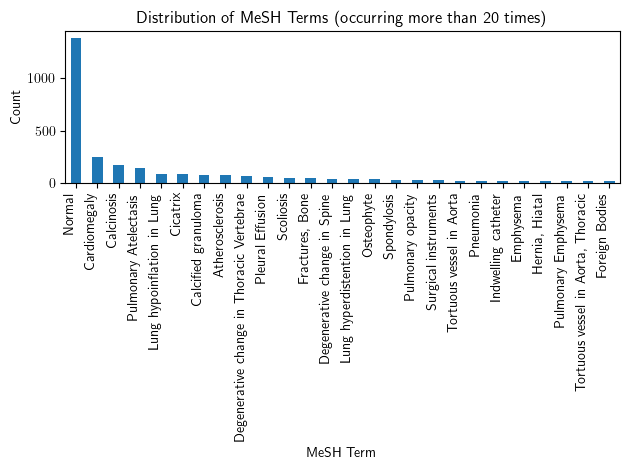

Number of unique MeSH labels: 126
Number of MeSH labels occurring more than 20 times: 26
Number of MeSH labels occurring 20 times or less: 100


In [85]:
uid_merged_exploded['MeSH_norm'].value_counts()[lambda x: x > 20].plot(kind='bar')
plt.title('Distribution of MeSH Terms (occurring more than 20 times)')
plt.xlabel('MeSH Term')
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

unique_labels = uid_merged_exploded['MeSH_norm'].unique().shape[0]
print(f"Number of unique MeSH labels: {unique_labels}")

labels_over_20 = uid_merged_exploded['MeSH_norm'].value_counts()[lambda x: x > 20].shape[0]
print(f"Number of MeSH labels occurring more than 20 times: {labels_over_20}")
labels_under_20 = unique_labels - labels_over_20
print(f"Number of MeSH labels occurring 20 times or less: {labels_under_20}")

In [86]:
import os

# Target minimum count per MeSH label
TARGET_COUNT = 10
THRESHOLD = 20
IMG_DIR = "./images/images_normalized"  # save augmented files here so existing loaders keep working
OUT_DIR = "./images/augmented"

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def augment_image(img, aug_type):
    h, w = img.shape[:2]

    if aug_type == "flip":
        return cv2.flip(img, 1)

    if aug_type == "rotate":
        angle = np.random.choice([-15, -10, 10, 15])
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)

    if aug_type == "zoom":
        scale = np.random.uniform(1.1, 1.25)
        nh, nw = int(h / scale), int(w / scale)
        y1, x1 = (h - nh) // 2, (w - nw) // 2
        cropped = img[y1:y1 + nh, x1:x1 + nw]
        return cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)

    if aug_type == "brightness":
        beta = np.random.randint(-30, 31)  # brightness shift
        out = img.astype(np.int16) + beta
        return np.clip(out, 0, 255).astype(np.uint8)

    return img

# Find rare labels (<20 occurrences)
label_counts = uid_merged_exploded["MeSH_norm"].value_counts()
rare_labels = label_counts[label_counts <= THRESHOLD]

# Build candidate rows per rare label
def has_label(mesh_value, label):
    # Check if the value is a string and matches the label
    return isinstance(mesh_value, str) and mesh_value.strip() == label

candidates = {
    label: uid_merged[uid_merged["MeSH_norm"].apply(lambda x, l=label: has_label(x, l))]
    for label in rare_labels.index
}

# Generate augmented rows
new_rows = []
next_uid = int(uid_merged["uid"].max()) + 1
aug_types = ["flip", "rotate", "zoom", "brightness"]

def create_augmented_images():
    global next_uid
    if len(os.listdir(OUT_DIR)) != 0:
        # If the directory isn't empty, we assume augmentation has already been done 
        # populate new_rows with existing augmented data to avoid duplication
        for fname in os.listdir(OUT_DIR):
            if fname.endswith(('.png', '.jpg', '.jpeg')):
                uid_part = fname.split('_')[2]  # Assuming format: stem_aug_{uid}_{aug_type}.ext
                try:
                    uid = int(uid_part)
                    original_row = uid_merged[uid_merged['uid'] == uid]
                    if not original_row.empty:
                        new_row = original_row.iloc[0].copy()
                        new_row['uid'] = next_uid
                        next_uid += 1
                        for col in ['image_1', 'image_2', 'image_3']:
                            if pd.notna(new_row[col]) and os.path.basename(new_row[col]) in fname:
                                new_row[col] = os.path.join(IMG_DIR, fname)
                        new_rows.append(new_row)
                except ValueError:
                    continue
        return
    else:
        for label, current_count in rare_labels.items():
            needed = TARGET_COUNT - current_count
            pool = candidates[label]
            if pool.empty:
                continue

            for _ in range(needed):
                row = pool.sample(1).iloc[0].copy()
                row["uid"] = next_uid
                next_uid += 1

                generated_any = False
                for col in ["image_1", "image_2", "image_3"]:
                    fname = row.get(col, np.nan)
                    if pd.isna(fname):
                        continue

                    src_path = os.path.join(IMG_DIR, fname)
                    img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)
                    if img is None:
                        continue


                    aug_type = np.random.choice(aug_types)
                    aug_img = augment_image(img, aug_type)

                    stem, ext = os.path.splitext(fname)
                    new_fname = f"{stem}_aug_{row['uid']}_{aug_type}{ext}"
                    cv2.imwrite(os.path.join(OUT_DIR, new_fname), aug_img)
                    row[col] = new_fname
                    generated_any = True

                if generated_any:
                    new_rows.append(row)



# New dataframes in the same structure as uid_merged
uid_merged_augmented_only = pd.DataFrame(new_rows, columns=uid_merged.columns)
uid_merged_with_aug = pd.concat([uid_merged, uid_merged_augmented_only], ignore_index=True)
uid_merged_with_aug_exploded = uid_merged_with_aug.explode("MeSH_norm")

print(f"Original rows: {len(uid_merged)}")
print(f"Augmented rows created: {len(uid_merged_augmented_only)}")
print(f"Total rows after augmentation: {len(uid_merged_with_aug)}")

Original rows: 3337
Augmented rows created: 0
Total rows after augmentation: 3337


In [68]:
uid_merged_augmented_only.to_csv("uid_merged_augmented_only.csv", index=False)

In [6]:
def preprocess_image(filename):
    if "aug" in filename:
        img = cv2.imread(os.path.join(OUT_DIR, filename), cv2.IMREAD_GRAYSCALE)
    else:
        img = cv2.imread('./images/images_normalized/' + filename, cv2.IMREAD_GRAYSCALE)
        
    img = cv2.resize(img, (224, 224))
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img

def get_original_image(filename):
    img = cv2.imread('./images/images_normalized/' + filename, cv2.IMREAD_GRAYSCALE)
    return img

In [88]:
plt.rcParams.update({
    "text.usetex": True,
})

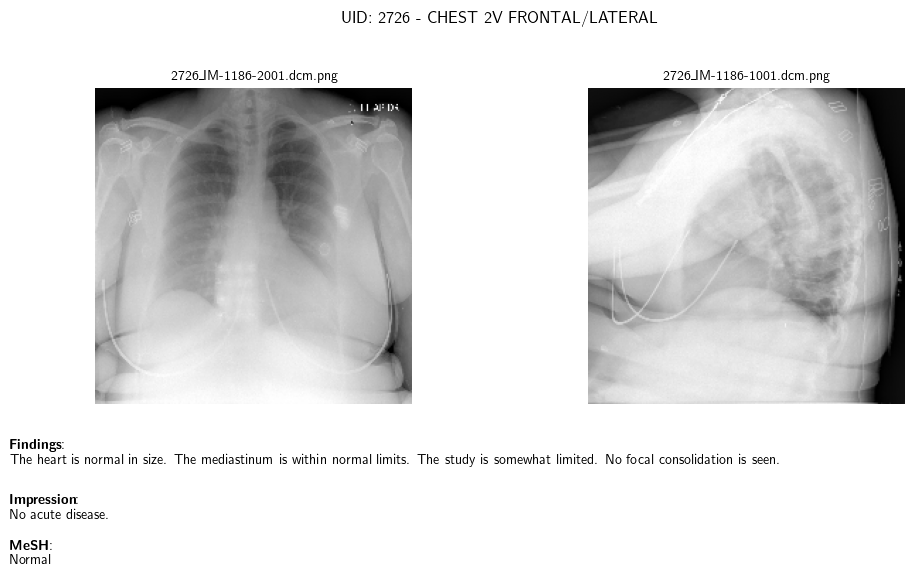

y = Normal


In [89]:
import textwrap

random_sample = uid_merged.sample(1)
row = random_sample.iloc[0]

image_files = [row[f"image_{i}"] for i in range(1, 4) if pd.notna(row[f"image_{i}"])]
images = [(f, preprocess_image(f)) for f in image_files]
images = [(f, img) for f, img in images if img is not None]

if len(images) == 0:
    print("No valid images found for this sample.")
else:
    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    if len(images) == 1:
        axes = [axes]

    for ax, (fname, img) in zip(axes, images):
        ax.imshow(img, cmap="gray")
        ax.set_title(fname, fontsize=10)
        ax.axis("off")

    findings_text = str(row["findings"]) if pd.notna(row["findings"]) else "N/A"
    impression_text = str(row["impression"]) if pd.notna(row["impression"]) else "N/A"
    mesh_text = row["MeSH_norm"] if pd.notna(row["MeSH_norm"]) else "N/A"

    # Wrap long lines nicely
    wrap = lambda s: "\n".join(textwrap.wrap(s, 200))

    y0 = 0.22    
    gap = 0.10  

    fig.suptitle(f"UID: {row['uid']} - {row['image']}", fontsize=12, y=0.98)

    fig.text(0.01, y0 - gap, r"$\textbf{Findings}$:"+f"\n{wrap(findings_text)}", ha="left", va="top", fontsize=10)
    fig.text(0.01, y0 - 2.1*gap, r"$\textbf{Impression}$:"+f"\n{wrap(impression_text)}", ha="left", va="top", fontsize=10)
    fig.text(0.01, y0 - 3*gap, r"$\textbf{MeSH}$:"+f"\n{wrap('; '.join(mesh_text) if isinstance(mesh_text, list) else mesh_text)}", ha="left", va="top", fontsize=10)

    plt.tight_layout(rect=[0, 0.16, 1, 0.92])
    plt.show()

    print(f"y = {mesh_text}")



In [90]:
def train_test_split(df, test_size=0.2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    shuffled_indices = np.random.permutation(len(df))
    test_set_size = int(len(df) * test_size)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return df.iloc[train_indices], df.iloc[test_indices]

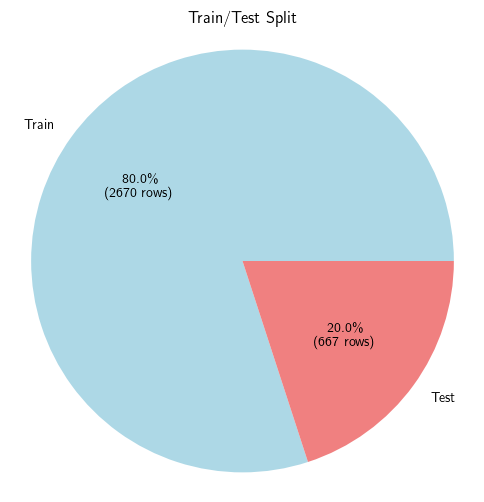

In [91]:
train, test = train_test_split(uid_merged, test_size=0.2, random_state=42)


def autopct_with_count(pct):
    count = int(round(pct / 100. * len(uid_merged)))
    return f"{pct:.1f}%\n({count} rows)"

plt.figure(figsize=(6, 6))
plt.pie([train.shape[0], test.shape[0]], labels=['Train', 'Test'], autopct=autopct_with_count, colors=['lightblue', 'lightcoral'])
plt.title('Train/Test Split')
plt.axis('equal')
plt.show()

In [92]:
df = uid_merged.copy()
df.fillna("None", inplace=True)
#df.drop(columns=['MeSH', "Problems"], inplace=True)
df.rename(columns={"MeSH_norm": "copt"}, inplace=True)
df[df['copt'].isna() | (df['copt'] == "None")]



,uid,MeSH,Problems,image,indication,comparison,findings,impression,image_1,image_2,image_3,copt


In [93]:
import random

def get_options(copt):
    if pd.isna(copt):
        print("NaN copt in get_options")
        return 
    all_options = set(uid_merged_exploded['MeSH_norm'].unique())
    removed_copt = list(filter (lambda x: x != copt, all_options))

    if len(removed_copt) < 3:
        print("Not enough options to sample from in get_options")
        return 

    options = [*random.sample(removed_copt, 3), copt]
    random.shuffle(options)
    return options

for row in df.itertuples():
    if pd.isna(row.copt):
        print("NaN copt at index", row.Index)
    options = get_options(row.copt)

    df.loc[row.Index, ['opt1', 'opt2', 'opt3', 'opt4']] = options

df.to_csv("processed_iuxray_mcqa_dataset.csv", index=False)

In [3]:
data = pd.read_csv("processed_iuxray_mcqa_dataset.csv")

df = data.copy()

In [95]:
for row in df.itertuples():
    findings = row.findings.lower() if pd.notna(row.findings) else ""
    copt = row.copt.lower()
    if copt in findings:
        findings = findings.replace(copt, "[mask]")
        df.at[row.Index, 'findings'] = findings

label_leak = 0

for row in df.itertuples():
    findings = row.findings.lower() if pd.notna(row.findings) else ""
    copt = row.copt.lower()

    if copt in findings:
        label_leak += 1
        if label_leak <= 10:  # Print the first few cases of label leak
            print(f"Label leak found in row {row.Index}:")
            print(f"Findings: {row.findings}")
            print(f"copt: {row.copt}")
            print("-" * 50)
    
print(f"Label leak: {label_leak / len(df) * 100:.2f} %")
print(f"Which is {label_leak}/{len(df)}")

df.to_csv("./processed_iuxray_mcqa_dataset.csv", index=False)

Label leak: 0.00 %
Which is 0/3337


In [96]:
label_leak = 0

for row in df.itertuples():
    findings = row.findings.lower() if pd.notna(row.findings) else ""
    copt = row.copt.lower()

    if copt in findings:
        label_leak += 1
        if label_leak <= 10:  # Print the first few cases of label leak
            print(f"Label leak found in row {row.Index}:")
            print(f"Findings: {row.findings}")
            print(f"copt: {row.copt}")
            print("-" * 50)
    
print(f"Label leak: {label_leak / len(df) * 100:.2f} %")
print(f"Which is {label_leak}/{len(df)}")

Label leak: 0.00 %
Which is 0/3337


In [98]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

normal_count = 0
for row in test_df.itertuples():
    findings = row.findings.lower() if pd.notna(row.findings) else ""
    copt = row.copt.lower()

    if copt == 'normal':
        normal_count += 1

print(f"Number of 'normal' cases in test set: {normal_count}")
print(f"Percentage of 'normal' cases in test set: {normal_count / len(test_df) * 100:.2f} %")

Number of 'normal' cases in test set: 271
Percentage of 'normal' cases in test set: 40.63 %


In [99]:
# check for duplicate findings in df

df[df.duplicated(subset=['findings'], keep=False)].sort_values(by='findings')

,uid,MeSH,Problems,image,indication,comparison,findings,impression,image_1,image_2,image_3,copt,opt1,opt2,opt3,opt4
1663,1963,normal,normal,Xray Chest PA and Lateral,MVC.,None.,2 images. heart size and pulmonary vascular en...,No acute cardiopulmonary abnormality identified.,1963_IM-0629-1001.dcm.png,1963_IM-0629-2001.dcm.png,NaN,Normal,Cardiomegaly,Normal,Elevated diaphragm in Diaphragm,Mastectomy
2163,2584,normal,normal,Xray Chest PA and Lateral,Chest pain for one XXXX.,"XXXX, XXXX.",2 images. heart size and pulmonary vascular en...,No acute cardiopulmonary abnormality identified.,2584_IM-1081-1001.dcm.png,2584_IM-1081-2001.dcm.png,NaN,Normal,Interstitial pattern in Lung,Normal,Small opacity in Opacity,Prominent finding in Opacity
2003,2389,normal,normal,Xray Chest PA and Lateral,XXXX and XXXX. Chest pain. Vomiting and diarrhea.,None.,2 images. heart size and pulmonary vascular en...,No acute cardiopulmonary abnormality identified.,2389_IM-0944-1001.dcm.png,2389_IM-0944-3001.dcm.png,NaN,Normal,Degenerative change in Cervical Vertebrae,Granulomatous disease,Normal,"Bone Diseases, Metabolic"
2676,3210,normal,normal,Xray Chest PA and Lateral,Chest pain. Liver pain.,None.,2 images. heart size and pulmonary vascular en...,No acute cardiopulmonary abnormality identified.,3210_IM-1517-1001.dcm.png,NaN,NaN,Normal,Normal,Lucency in ribs right posterior,Enlarged structure in Lung,Bilateral abnormality in Epicardial Fat
1497,1766,normal,normal,Xray Chest PA and Lateral,Dizziness and shortness of breath. Lightheaded...,"XXXX, XXXX.",2 images. heart size and pulmonary vascular en...,No acute cardiopulmonary abnormality identified.,1766_IM-0500-1001.dcm.png,1766_IM-0500-2001.dcm.png,NaN,Normal,Pleural Effusion,Degenerative change in Spine,"Fractures, Bone",Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2306,2768,normal,normal,"Chest PA and lateral views. XXXX, XXXX XXXX PM...",Chest pain.,NaN,xxxx xxxx and lateral chest examination was ob...,No acute pulmonary disease.,2768_IM-1212-1001.dcm.png,2768_IM-1212-2001.dcm.png,NaN,Normal,Normal,Subcutaneous Emphysema,Arthritis,Streaky opacity in Opacity
3000,3588,normal,normal,"Chest PA and lateral views. XXXX, XXXX XXXX PM",sob,XXXX,xxxx xxxx and lateral chest examination was ob...,1. No acute pulmonary disease.,3588_IM-1766-1001.dcm.png,3588_IM-1766-2001.dcm.png,NaN,Normal,"Fractures, Bone",Blister,Normal,Airspace disease
2619,3143,normal,normal,"Chest PA and lateral views. XXXX, XXXX XXXX PM",dizziness,none,xxxx xxxx and lateral chest examination was ob...,1. No acute pulmonary disease.,3143_IM-1477-1001.dcm.png,3143_IM-1477-2001.dcm.png,NaN,Normal,Lucency in clavicle right,Contrast media,Bilateral abnormality in Bullous Emphysema,Normal
1125,1335,normal,normal,"Chest PA and lateral views. XXXX, XXXX XXXX PM",upper back pain,"XXXX, XXXX",xxxx xxxx and lateral chest examination was ob...,1. No acute pulmonary disease.,1335_IM-0215-1001.dcm.png,1335_IM-0215-1002.dcm.png,NaN,Normal,"Pulmonary Disease, Chronic Obstructive",Focal abnormality in Opacity,Normal,Bilateral abnormality in Pulmonary Congestion


In [7]:
import os
image_files = os.listdir("./images/images_normalized/")
save_dir = "./images/processed/"

for fname in image_files:
    img = preprocess_image(fname)
    if img is not None:
        out = (img * 255).astype(np.uint8)
        cv2.imwrite(os.path.join(save_dir, fname), out)
